In [ ]:
from pathlib import Path
from joblib import Memory
from google.cloud import storage

from vacant_lot.config import load_config
from vacant_lot.gee_utils import (
    init_gee,
    load_image_collection,
    # Vector workflow functions
    upload_parcels_to_gcs,
    ingest_parcels_to_gee,
    reduce_regions_to_gcs,
    # Raster workflow functions (for reference)
    upload_raster_to_gcs,
    ingest_raster_to_gee,
)
from vacant_lot.data_utils import upload_to_gcs
from vacant_lot.analysis import cluster_spectral_data
from vacant_lot.mappluto import load_and_sample
from vacant_lot.geometry import get_city_geometry
from vacant_lot.naip import calculate_spectral_indices
from vacant_lot.raster_utils import rasterize_parcels
from vacant_lot.analysis import (
    read_csv_from_gcs,
    analyze_cluster_composition,
    cluster_dataframe
)
from vacant_lot.plotting import plot_pca, plot_cluster_composition, plot_feature_importance, plot_pca_loadings

In [2]:
# ===== RUN CONFIGURATION =====
CONFIG_FILE = "nyc_buildings.yaml"  # Change to "nyc_buildings", etc.
# =============================

memory = Memory(Path("cache"), verbose=0)

# Load run-specific config
CONFIG = load_config(CONFIG_FILE)

# Create output directories
CONFIG.ensure_output_dirs()

# gcs client
client = storage.Client()
bucket = client.bucket(CONFIG.gcp.bucket)

16:41:57 | INFO | vacant_lots | Loaded config for: nyc_buildings.yaml


In [3]:
init_gee(CONFIG.gcp)

16:42:00 | INFO | vacant_lots | Initializing GEE with ADC credentials and project:vacant-lot-detection
16:42:01 | INFO | vacant_lots | GEE sucessfully initialized


In [ ]:
"""
- Load MapPLUTO (NYC) 2022 v3 -- fall matches with NAIP
- Reproject to output_crs (EPSG:32618) for geometry-derived metric area computation
- Filter by area: min from min_pixels × resolution²
- Sample vacant lots based on land use codes (configurable)
- Returns GeoDataFrames in EPSG:32618 (projected CRS)
- NOTE: If GEE uploads are re-enabled, data must be converted to EPSG:4326 first
"""
mappluto_22_gdf, sampled_gdf = load_and_sample(
    path=CONFIG.get_parcel_path(),
    layer=CONFIG.parcel.layer,
    land_use_codes=CONFIG.parcel.vacant_codes,
    col_to_sample=CONFIG.parcel.landuse_column,
    projected_crs=CONFIG.raster.output_crs,
    vacant_min_fraction=CONFIG.sampling.vacant_min_fraction,
    total_samples=CONFIG.sampling.total_samples,
    resolution=CONFIG.raster.resolution,
    min_pixels=CONFIG.sampling.min_pixels,
    random_state=CONFIG.sampling.random_state,
)

In [5]:
city_geom = get_city_geometry(CONFIG)

@memory.cache
def get_naip_for_city(config):
    return load_image_collection(
        collection_id=config.naip.collection_id,
        start_date=config.naip.start_date,
        end_date=config.naip.end_date,
        region=city_geom,
        mosaic=True
    )

naip = get_naip_for_city(CONFIG)
naip = calculate_spectral_indices(naip, CONFIG)

16:43:05 | INFO | vacant_lots | Loading geometry from TIGER counties: ['New York', 'Kings', 'Queens', 'Bronx', 'Richmond'] (state FIPS: 36)
16:43:05 | INFO | vacant_lots | Geometry loaded successfully
16:43:05 | INFO | vacant_lots | Loading ImageCollection: USDA/NAIP/DOQQ
16:43:05 | INFO | vacant_lots | Date range: 2022-01-01 → 2022-12-31
16:43:05 | INFO | vacant_lots | FilterBounds by region
16:43:05 | INFO | vacant_lots | Filtered collection contains 62 images
16:43:05 | INFO | vacant_lots | Creating mosaic from filtered collection
16:43:05 | INFO | vacant_lots | Mosaic created successfully
16:43:05 | INFO | vacant_lots | Clipping mosaiced image
16:43:05 | INFO | vacant_lots | scaling ['R', 'G', 'B', 'N'] by 255.0
16:43:05 | INFO | vacant_lots | calculating NDVI
16:43:05 | INFO | vacant_lots | scaling NDVI to [0,1]
16:43:05 | INFO | vacant_lots | calculating SAVI
16:43:05 | INFO | vacant_lots | clamping SAVI values [-1, 1]
16:43:05 | INFO | vacant_lots | scaling SAVI values to [0,1]


# Vector Based Reduction

## Parcel Table Ingestion to GEE
- run when parcels should be overwritten in both gcs and gee 

In [ ]:
# gcs_uri = upload_parcels_to_gcs(
#     gdf=sampled_gdf,
#     id_column=CONFIG.parcel.id_column,
#     output_dir=CONFIG.get_intermediaries_dir(),
#     bucket_name=CONFIG.gcp.bucket,
#     gcs_prefix=CONFIG.gee.export_prefix,
#     filename_prefix=f"parcels",
# )

In [ ]:
# ingest_parcels_to_gee(
#     asset_id=f"projects/{CONFIG.gcp.project_id}/assets/{CONFIG.city}_{CONFIG.run_name}_parcels",
#     gcs_uri=gcs_uri,
# )

"""
Can provide bucket_name, gcs_prefix, gcs_filename if cell above doesn't need to be re run 
f"gs://{bucket_name}/{gcs_prefix}/{gcs_filename}"
"""
# ingest_parcels_to_gee(
#     asset_id=f"projects/{CONFIG.gcp.project_id}/assets/{CONFIG.city}_parcels",
#     bucket_name=CONFIG.gcp.bucket,
#     gcs_prefix=CONFIG.gee.export_prefix,
#     gcs_filename=f"{CONFIG.city}_parcels.zip",
# )

17:52:53 | INFO | vacant_lots | Ingesting gs://thesis_parcels/eda/new_york_new_york_bldgclss/parcels.zip → projects/vacant-lot-detection/assets/nyc_buildings_parcels
17:52:53 | INFO | vacant_lots | Ingestion task started: MEBQKQLF7MR5KTSNECKMRAXL


'\nCan provide bucket_name, gcs_prefix, gcs_filename if cell above doesn\'t need to be re run \nf"gs://{bucket_name}/{gcs_prefix}/{gcs_filename}"\n'

## Reduce Pixel Values Per Parcel
- only run once after asset exists in gee --> uploads a csv of parcel_identifier, avg_spectral_stat_1, avg_spectral_stat_2, ..., avg_spectral_stat_n to gcs

In [ ]:
# task = reduce_regions_to_gcs(
#     imagery=naip,
#     parcels_asset_id=f"projects/{CONFIG.gcp.project_id}/assets/{CONFIG.city}_{CONFIG.run_name}_parcels",
#     bucket_name=CONFIG.gcp.bucket,
#     gcs_prefix=CONFIG.gee.export_prefix,
#     include_count=True,
# )

17:56:36 | INFO | vacant_lots | Loading parcels from asset: projects/vacant-lot-detection/assets/nyc_buildings_parcels
17:56:36 | INFO | vacant_lots | Running reduceRegions with scale=1, tileScale=4
17:56:36 | INFO | vacant_lots | Exporting to gs://thesis_parcels/eda/new_york_new_york_bldgclss/parcel_spectral_stats.csv
17:56:36 | INFO | vacant_lots | Export task started: G4DDYBBKJO55CMD2YX2H6CGA


## Start here to get the Parcel by Parcel Spectral Stats

In [6]:
spectral_df = read_csv_from_gcs(CONFIG.gcp.bucket, f"{CONFIG.gee.export_prefix}/parcel_spectral_stats.csv")
spectral_df

16:43:06 | INFO | vacant_lots | Reading CSV from gs://thesis_parcels/eda/new_york_new_york_bldgclss/parcel_spectral_stats.csv
16:43:08 | INFO | vacant_lots | Loaded 25000 rows, 35 columns


,system:index,BBL,B_count,B_mean,B_median,B_stdDev,BareSoilProxy_count,BareSoilProxy_mean,BareSoilProxy_median,BareSoilProxy_stdDev,...,N_stdDev,R_count,R_mean,R_median,R_stdDev,SAVI_count,SAVI_mean,SAVI_median,SAVI_stdDev,.geo
0,00000000000000000000,3.043150e+09,2647,0.518623,0.549020,0.113570,2647,0.228910,0.268602,0.094596,...,0.166184,2647,0.481768,0.560784,0.184515,2647,0.559745,0.514665,0.088294,"{""type"":""Polygon"",""coordinates"":[[[-73.8801654..."
1,00000000000000000001,5.001530e+09,541,0.377671,0.325490,0.136553,541,0.153603,0.133777,0.076459,...,0.244083,541,0.350645,0.360784,0.164858,541,0.604758,0.631759,0.087222,"{""type"":""Polygon"",""coordinates"":[[[-74.1094122..."
2,00000000000000000002,5.045820e+09,12824,0.346624,0.349020,0.028908,12824,0.092108,0.091317,0.034564,...,0.086114,12824,0.288427,0.294118,0.093397,12824,0.734503,0.736854,0.036726,"{""type"":""Polygon"",""coordinates"":[[[-74.1502174..."
3,00000000000000000003,2.059420e+09,4054,0.407837,0.345098,0.154955,4054,0.195413,0.145540,0.114205,...,0.103504,4054,0.479932,0.423529,0.180300,4054,0.614564,0.655365,0.104298,"{""type"":""Polygon"",""coordinates"":[[[-73.9103847..."
4,00000000000000000004,5.029100e+09,682,0.640577,0.647059,0.106547,682,0.340832,0.354546,0.061474,...,0.133367,682,0.665038,0.686275,0.122035,682,0.480630,0.471627,0.041565,"{""type"":""Polygon"",""coordinates"":[[[-74.0884946..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,000000000000000061a3,3.019180e+09,321,0.599905,0.627451,0.239893,321,0.269203,0.316823,0.154406,...,0.085820,321,0.595301,0.670588,0.254123,321,0.596713,0.513897,0.105470,"{""type"":""Polygon"",""coordinates"":[[[-73.9658292..."
24996,000000000000000061a4,3.048910e+09,268,0.674307,0.694118,0.172860,268,0.328112,0.360553,0.100453,...,0.194401,268,0.668674,0.749020,0.187906,268,0.522476,0.498641,0.064822,"{""type"":""Polygon"",""coordinates"":[[[-73.9426686..."
24997,000000000000000061a5,4.163050e+09,614,0.550455,0.537255,0.131414,614,0.284939,0.285797,0.086435,...,0.220601,614,0.550261,0.521569,0.191347,614,0.481617,0.467565,0.069146,"{""type"":""Polygon"",""coordinates"":[[[-73.8652096..."
24998,000000000000000061a6,5.003010e+09,344,0.396045,0.356863,0.153475,344,0.184944,0.165908,0.097695,...,0.182333,344,0.363848,0.372549,0.171630,344,0.530433,0.496938,0.077581,"{""type"":""Polygon"",""coordinates"":[[[-74.1112806..."


In [7]:
mappluto_features = sampled_gdf[["BBL", f"{CONFIG.parcel.landuse_column}", "geometry", "geom_perimeter_epsg32618", "area_m2_epsg32618"]].copy()
mappluto_features

,BBL,BldgClass,geometry,geom_perimeter_epsg32618,area_m2_epsg32618
178131,3.043150e+09,V0,"MULTIPOLYGON (((-73.8795 40.66662, -73.87981 4...",198.513075,1900.597522
813138,5.001530e+09,V0,"MULTIPOLYGON (((-74.10912 40.63314, -74.10941 ...",79.611469,374.128677
688407,5.045820e+09,V1,"MULTIPOLYGON (((-74.15022 40.5617, -74.15063 4...",434.233454,9472.449006
187100,2.059420e+09,V0,"MULTIPOLYGON (((-73.90938 40.90138, -73.90927 ...",443.873982,2853.847988
833426,5.029100e+09,G7,"MULTIPOLYGON (((-74.08827 40.60744, -74.0885 4...",91.518486,464.176519
...,...,...,...,...,...
132888,3.019180e+09,A9,"MULTIPOLYGON (((-73.96548 40.69077, -73.96555 ...",73.909902,209.395800
241373,3.048910e+09,B9,"MULTIPOLYGON (((-73.9423 40.65063, -73.94267 4...",72.998962,170.882974
617469,4.163050e+09,A1,"MULTIPOLYGON (((-73.86488 40.57155, -73.86521 ...",88.782353,420.672190
624269,5.003010e+09,A5,"MULTIPOLYGON (((-74.11128 40.62631, -74.11129 ...",70.944752,226.528868


In [8]:
mappluto_features

,BBL,BldgClass,geometry,geom_perimeter_epsg32618,area_m2_epsg32618
178131,3.043150e+09,V0,"MULTIPOLYGON (((-73.8795 40.66662, -73.87981 4...",198.513075,1900.597522
813138,5.001530e+09,V0,"MULTIPOLYGON (((-74.10912 40.63314, -74.10941 ...",79.611469,374.128677
688407,5.045820e+09,V1,"MULTIPOLYGON (((-74.15022 40.5617, -74.15063 4...",434.233454,9472.449006
187100,2.059420e+09,V0,"MULTIPOLYGON (((-73.90938 40.90138, -73.90927 ...",443.873982,2853.847988
833426,5.029100e+09,G7,"MULTIPOLYGON (((-74.08827 40.60744, -74.0885 4...",91.518486,464.176519
...,...,...,...,...,...
132888,3.019180e+09,A9,"MULTIPOLYGON (((-73.96548 40.69077, -73.96555 ...",73.909902,209.395800
241373,3.048910e+09,B9,"MULTIPOLYGON (((-73.9423 40.65063, -73.94267 4...",72.998962,170.882974
617469,4.163050e+09,A1,"MULTIPOLYGON (((-73.86488 40.57155, -73.86521 ...",88.782353,420.672190
624269,5.003010e+09,A5,"MULTIPOLYGON (((-74.11128 40.62631, -74.11129 ...",70.944752,226.528868


In [9]:
# spectral only clustering 
mappluto_spectral_df = mappluto_features[["BBL", f"{CONFIG.parcel.landuse_column}"]].copy()

#join on bbl with spectral df 
merged_df = spectral_df.merge(mappluto_spectral_df, on="BBL", how="left")
merged_df

,system:index,BBL,B_count,B_mean,B_median,B_stdDev,BareSoilProxy_count,BareSoilProxy_mean,BareSoilProxy_median,BareSoilProxy_stdDev,...,R_count,R_mean,R_median,R_stdDev,SAVI_count,SAVI_mean,SAVI_median,SAVI_stdDev,.geo,BldgClass
0,00000000000000000000,3.043150e+09,2647,0.518623,0.549020,0.113570,2647,0.228910,0.268602,0.094596,...,2647,0.481768,0.560784,0.184515,2647,0.559745,0.514665,0.088294,"{""type"":""Polygon"",""coordinates"":[[[-73.8801654...",V0
1,00000000000000000001,5.001530e+09,541,0.377671,0.325490,0.136553,541,0.153603,0.133777,0.076459,...,541,0.350645,0.360784,0.164858,541,0.604758,0.631759,0.087222,"{""type"":""Polygon"",""coordinates"":[[[-74.1094122...",V0
2,00000000000000000002,5.045820e+09,12824,0.346624,0.349020,0.028908,12824,0.092108,0.091317,0.034564,...,12824,0.288427,0.294118,0.093397,12824,0.734503,0.736854,0.036726,"{""type"":""Polygon"",""coordinates"":[[[-74.1502174...",V1
3,00000000000000000003,2.059420e+09,4054,0.407837,0.345098,0.154955,4054,0.195413,0.145540,0.114205,...,4054,0.479932,0.423529,0.180300,4054,0.614564,0.655365,0.104298,"{""type"":""Polygon"",""coordinates"":[[[-73.9103847...",V0
4,00000000000000000004,5.029100e+09,682,0.640577,0.647059,0.106547,682,0.340832,0.354546,0.061474,...,682,0.665038,0.686275,0.122035,682,0.480630,0.471627,0.041565,"{""type"":""Polygon"",""coordinates"":[[[-74.0884946...",G7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,000000000000000061a3,3.019180e+09,321,0.599905,0.627451,0.239893,321,0.269203,0.316823,0.154406,...,321,0.595301,0.670588,0.254123,321,0.596713,0.513897,0.105470,"{""type"":""Polygon"",""coordinates"":[[[-73.9658292...",A9
24996,000000000000000061a4,3.048910e+09,268,0.674307,0.694118,0.172860,268,0.328112,0.360553,0.100453,...,268,0.668674,0.749020,0.187906,268,0.522476,0.498641,0.064822,"{""type"":""Polygon"",""coordinates"":[[[-73.9426686...",B9
24997,000000000000000061a5,4.163050e+09,614,0.550455,0.537255,0.131414,614,0.284939,0.285797,0.086435,...,614,0.550261,0.521569,0.191347,614,0.481617,0.467565,0.069146,"{""type"":""Polygon"",""coordinates"":[[[-73.8652096...",A1
24998,000000000000000061a6,5.003010e+09,344,0.396045,0.356863,0.153475,344,0.184944,0.165908,0.097695,...,344,0.363848,0.372549,0.171630,344,0.530433,0.496938,0.077581,"{""type"":""Polygon"",""coordinates"":[[[-74.1112806...",A5


In [10]:
# Kmeans + PCA clustering

merged_df, models = cluster_dataframe(
    df=merged_df,
    feature_columns=CONFIG.clustering.features if CONFIG.clustering else None,
    n_clusters=CONFIG.clustering.n_clusters if CONFIG.clustering else 5,
    random_state=CONFIG.clustering.random_state if CONFIG.clustering else 42,
    add_pca=True,
)
merged_df

16:43:22 | INFO | vacant_lots | Starting clustering pipeline with 8 features
16:43:22 | INFO | vacant_lots | Features: ['B_mean', 'G_mean', 'R_mean', 'N_mean', 'NDVI_mean', 'SAVI_mean', 'Brightness_mean', 'BareSoilProxy_mean']
16:43:22 | INFO | vacant_lots | Found 16 NaN values
16:43:22 | INFO | vacant_lots | Scaling features with StandardScaler
16:43:22 | INFO | vacant_lots | Running KMeans with 5 clusters
16:43:22 | INFO | vacant_lots |   Cluster 0: 5353 samples (21.4%)
16:43:22 | INFO | vacant_lots |   Cluster 1: 2421 samples (9.7%)
16:43:22 | INFO | vacant_lots |   Cluster 2: 3551 samples (14.2%)
16:43:22 | INFO | vacant_lots |   Cluster 3: 7782 samples (31.1%)
16:43:22 | INFO | vacant_lots |   Cluster 4: 5893 samples (23.6%)
16:43:22 | INFO | vacant_lots | Running PCA with 2 components
16:43:22 | INFO | vacant_lots |   PC1 explained variance: 75.1%
16:43:22 | INFO | vacant_lots |   PC2 explained variance: 23.6%
16:43:22 | INFO | vacant_lots |   Total explained variance: 98.7%
16:4

,system:index,BBL,B_count,B_mean,B_median,B_stdDev,BareSoilProxy_count,BareSoilProxy_mean,BareSoilProxy_median,BareSoilProxy_stdDev,...,R_stdDev,SAVI_count,SAVI_mean,SAVI_median,SAVI_stdDev,.geo,BldgClass,cluster,pc1,pc2
0,00000000000000000000,3.043150e+09,2647,0.518623,0.549020,0.113570,2647,0.228910,0.268602,0.094596,...,0.184515,2647,0.559745,0.514665,0.088294,"{""type"":""Polygon"",""coordinates"":[[[-73.8801654...",V0,4,-1.708103,-0.000524
1,00000000000000000001,5.001530e+09,541,0.377671,0.325490,0.136553,541,0.153603,0.133777,0.076459,...,0.164858,541,0.604758,0.631759,0.087222,"{""type"":""Polygon"",""coordinates"":[[[-74.1094122...",V0,1,-4.599169,0.523278
2,00000000000000000002,5.045820e+09,12824,0.346624,0.349020,0.028908,12824,0.092108,0.091317,0.034564,...,0.093397,12824,0.734503,0.736854,0.036726,"{""type"":""Polygon"",""coordinates"":[[[-74.1502174...",V1,1,-6.723992,4.739897
3,00000000000000000003,2.059420e+09,4054,0.407837,0.345098,0.154955,4054,0.195413,0.145540,0.114205,...,0.180300,4054,0.614564,0.655365,0.104298,"{""type"":""Polygon"",""coordinates"":[[[-73.9103847...",V0,1,-2.844289,1.933521
4,00000000000000000004,5.029100e+09,682,0.640577,0.647059,0.106547,682,0.340832,0.354546,0.061474,...,0.122035,682,0.480630,0.471627,0.041565,"{""type"":""Polygon"",""coordinates"":[[[-74.0884946...",G7,3,2.247173,-1.317664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,000000000000000061a3,3.019180e+09,321,0.599905,0.627451,0.239893,321,0.269203,0.316823,0.154406,...,0.254123,321,0.596713,0.513897,0.105470,"{""type"":""Polygon"",""coordinates"":[[[-73.9658292...",A9,4,0.080174,2.428928
24996,000000000000000061a4,3.048910e+09,268,0.674307,0.694118,0.172860,268,0.328112,0.360553,0.100453,...,0.187906,268,0.522476,0.498641,0.064822,"{""type"":""Polygon"",""coordinates"":[[[-73.9426686...",B9,0,2.233225,0.383393
24997,000000000000000061a5,4.163050e+09,614,0.550455,0.537255,0.131414,614,0.284939,0.285797,0.086435,...,0.191347,614,0.481617,0.467565,0.069146,"{""type"":""Polygon"",""coordinates"":[[[-73.8652096...",A1,2,0.082482,-2.347063
24998,000000000000000061a6,5.003010e+09,344,0.396045,0.356863,0.153475,344,0.184944,0.165908,0.097695,...,0.171630,344,0.530433,0.496938,0.077581,"{""type"":""Polygon"",""coordinates"":[[[-74.1112806...",A5,2,-3.802428,-2.204203


16:43:26 | INFO | vacant_lots | Saved PCA plot to /path/to/Vacant_Lot_Detection/outputs/eda/nyc_buildings/figures/pca_clusters.png


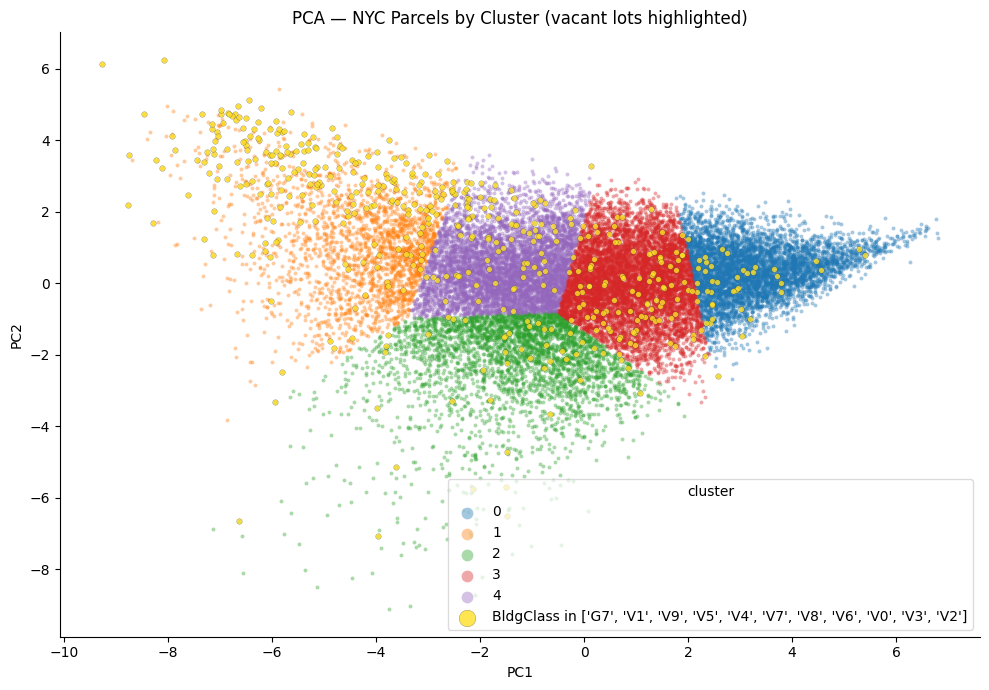

PosixPath('/path/to/Vacant_Lot_Detection/outputs/eda/nyc_buildings/figures/pca_clusters.png')

In [11]:
plot_pca(                                                                                                                                      
    df=merged_df,                                                                                                                              
    output_dir=CONFIG.get_figures_dir(),
    color_col="cluster",
    highlight_col=CONFIG.parcel.landuse_column,
    highlight_value=CONFIG.parcel.vacant_codes,   # vacant lots drawn on top in yellow
    title="PCA — NYC Parcels by Cluster (vacant lots highlighted)",
)

/path/to/Vacant_Lot_Detection/worktree-migration-data-paths/vacant_lot/plotting.py:293: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


16:43:30 | INFO | vacant_lots | Saved cluster composition plot to /path/to/Vacant_Lot_Detection/outputs/eda/nyc_buildings/figures/cluster_composition.png


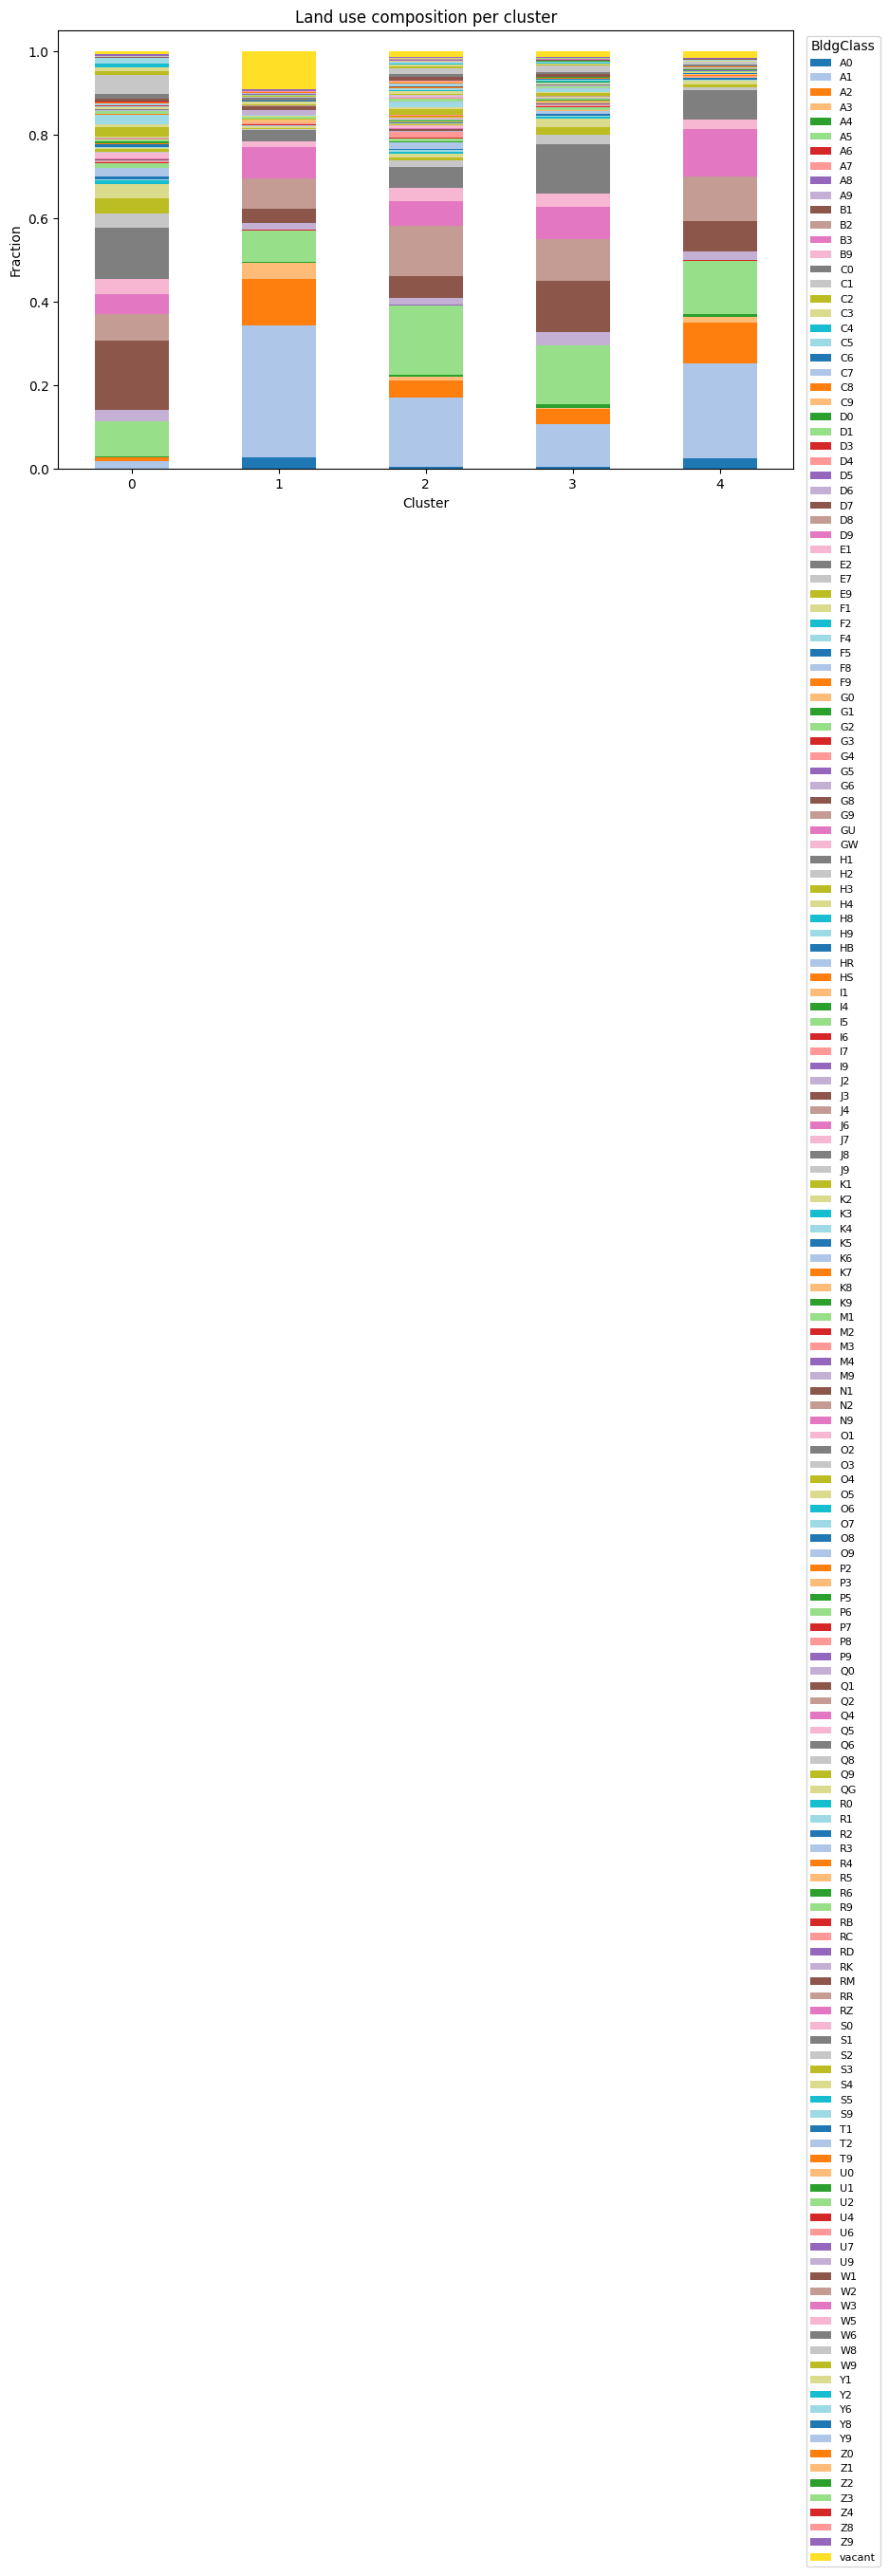

In [12]:
out_path, composition_df = plot_cluster_composition(merged_df, output_dir=CONFIG.get_figures_dir(), category_col=CONFIG.parcel.landuse_column, vacant_codes=CONFIG.parcel.vacant_codes)

In [ ]:
plot_pca_loadings(models, output_dir=CONFIG.get_figures_dir())

In [ ]:
plot_feature_importance(models, output_dir=CONFIG.get_figures_dir())

# Rasterize Parcels

In [ ]:
# raster_output_path = CONFIG.get_raster_path(REPO_ROOT)
# intermediaries_dir = CONFIG.get_intermediaries_dir(REPO_ROOT)
# mapping_output_path = intermediaries_dir / "parcel_id_mapping.csv"

# raster_path, mapping_path = rasterize_parcels(
#     gdf=mappluto_22_gdf,
#     id_column=CONFIG.parcel.id_column,
#     raster_output_path=raster_output_path,
#     mapping_output_path=mapping_output_path,
#     crs=CONFIG.raster.output_crs,
#     resolution=CONFIG.raster.resolution,
#     overwrite=False,
# )

The following cell should only be run once when the raster needs to be uploaded to gcs and then ingested to gee

In [ ]:
# ## Upload parcel raster to GEE

# # Upload to GCS first
# gcs_uri = upload_raster_to_gcs(
#     raster_path=raster_path,
#     gcs_bucket=CONFIG.gcp.bucket,
#     gcs_prefix=CONFIG.gee.export_prefix,
#     gcs_filename="parcels_raster.tif",
# )

# # Ingest to GEE asset
# task_info = ingest_raster_to_gee(
#     gcs_uri=gcs_uri,
#     asset_id=CONFIG.gee.parcel_asset,
# )

# # Task runs asynchronously - check progress in Earth Engine Code Editor
# print(f"Task {task_info['task_id']} submitted")
# print(f"Check progress at: https://code.earthengine.google.com/tasks")

## Raster-Based Parcel Reduction

Instead of using `reduceRegions()` with vector polygons (which is slow for many parcels), we can use a grouped reducer with the parcel raster. This approach:
1. Uploads the parcel raster to GEE as an Image asset
2. Stacks the imagery bands with the parcel ID band
3. Uses `reduceRegion()` with a grouped reducer to compute stats per parcel ID

Only upload to GEE when raster asset for a specific city needs to be overwritten. This is a time consuming process.

In [ ]:
# # Raster-based grouped reducer with ONLY sampled parcels
# from vacant_lot.gee_utils import load_parcel_raster_asset, reduce_by_parcel_raster, export_grouped_stats_to_gcs
# import pandas as pd

# # Load parcel raster from GEE
# parcel_raster_asset = CONFIG.gee.parcel_asset
# parcel_raster = load_parcel_raster_asset(parcel_raster_asset)

# # Load the parcel_id mapping (BBL -> rasterized integer ID)
# mapping_path = CONFIG.get_intermediaries_dir(REPO_ROOT) / "parcel_id_mapping.csv"
# parcel_mapping = pd.read_csv(mapping_path)
# print(f"Loaded parcel mapping: {len(parcel_mapping)} parcels")

# # Get the rasterized IDs for sampled parcels only
# # Join sampled_gdf with mapping on BBL
# sampled_bbls = sampled_gdf['BBL'].astype(int).tolist()
# sampled_mapping = parcel_mapping[parcel_mapping['BBL'].isin(sampled_bbls)]
# sampled_parcel_ids = sampled_mapping['parcel_id'].tolist()
# print(f"Sampled parcels with mapping: {len(sampled_parcel_ids)}")

# # Verify bands
# print("NAIP bands:", naip.bandNames().getInfo())
# bands_to_reduce = ['R', 'G', 'B', 'N', 'NDVI', 'SAVI', 'Brightness', 'BareSoilProxy']

# naip_32618 = naip.reproject("EPSG:32618")
# # Run reduction with ONLY sampled parcel IDs
# grouped_stats = reduce_by_parcel_raster(
#     imagery=naip_32618,
#     parcel_raster=parcel_raster,
#     region=city_geom,
#     bands=bands_to_reduce,
#     scale=1,
#     debug=True,
#     parcel_ids=sampled_parcel_ids,  # Only process sampled parcels!
# )

# # Export results to GCS with new path structure
# task = export_grouped_stats_to_gcs(
#     stats_dict=grouped_stats,
#     description='parcel_spectral_stats_raster',
#     bucket=CONFIG.gcp.bucket,
#     file_prefix=f'{CONFIG.gee.export_prefix}/parcel_spectral_stats_raster',  # New path: eda/new_york_new_york/
# )

In [ ]:
# Generate README for this run
from vacant_lot.config import generate_run_readme

run_stats = {
    "Total parcels loaded": len(mappluto_22_gdf),
    "Sampled parcels": len(sampled_gdf),
    "Land use codes": sorted(sampled_gdf[CONFIG.parcel.landuse_column].unique()),
    "Unique clusters": len(merged_df['cluster'].unique()),
    "Total spectral features": len(CONFIG.clustering.features),
}

generate_run_readme(
    config=CONFIG,
    output_dir=CONFIG.get_output_dir(),
    stats=run_stats,
)